In [2]:
from scipy.stats import spearmanr
from scipy.stats import pearsonr
import matplotlib.pyplot as plt
import os
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
# import import_ipynb
from scipy.interpolate import PchipInterpolator
# import seaborn as sns

def interpolador(subject, method, size):
    # data = np.array([int(line.strip()) for line in subject.to_numpy()])  # Si lo obtienes de un DataFrame
    data = subject
    x = np.arange(len(data))
    
    # Crear 'size' puntos equidistantes
    x_new = np.linspace(0, len(data) - 1, size*(len(data)-1) + len(data))
    
    if method == 'lineal':
        data_interp = np.interp(x_new, x, data)
    elif method == 'herm':
        interpolator = PchipInterpolator(x, data)
        data_interp = interpolator(x_new)
    
    return x_new, data_interp

def interpolador_constante(subject):
    # data = np.array([int(line.strip()) for line in subject.to_numpy()])  # Si lo obtienes de un DataFrame
    x = np.arange(2)
    data_interp = np.array([])
    diferencias =np.abs(np.diff(subject))
    if (np.max(diferencias) - np.min(diferencias)) <= 1e-5:
        return subject
    diferencias_sin_0 = diferencias[diferencias != 0]
    diferencias = np.round(diferencias/np.min(diferencias_sin_0))
    for i in range(len(subject)-1):
        data = subject[i:i+2]
        if diferencias[i] == 0:
            data_interp = np.concatenate((data_interp,data[:-1]))
            continue
        size = int(diferencias[i])- 1
        # Crear 'size' puntos equidistantes
        x_new = np.linspace(0, 1, size + 2)
        interp_step = np.interp(x_new, x, data)
        data_interp = np.concatenate((data_interp,interp_step[:-1]))
    data_interp = np.concatenate((data_interp,np.array([data[-1]])))

    return data_interp

def discretizar(array, num_partitions):
    if num_partitions == 1:
        print(" Minimo de particiones: 2")
        return np.array([])
    window = (np.abs(np.min(array)) + np.abs(np.max(array)))/(num_partitions - 1)
    discretizador = [np.min(array)+window*(i) for i in range(num_partitions)]
    if discretizador[len(discretizador)-1] != np.max(array):
        discretizador[len(discretizador)-1] = np.max(array)
    array_discreto = []
    for i,valor in enumerate(array):
        array_discreto.append(min(discretizador, key=lambda x: abs(x - valor)))

    return array_discreto

def discretizar_x(array_y, num_partitions):
    if num_partitions == 1:
        print(" Minimo de particiones: 2")
        return np.array([])
    array_x = range(int(len(array_y)))
    window = (len(array_x))/(num_partitions - 1)
    x_discreto = [int(window*(i)) for i in range(num_partitions)]
    array_discreto = []
    for i in x_discreto[0:len(x_discreto)-1]:
        array_discreto.append(array_y[i])
    array_discreto.append(array_y[len(array_x)-1])

    return x_discreto, array_discreto

def arm_detector(data, num_ventanas=25, b=0.6):
    n = len(data)
    x = np.arange(n)
    
    # Calcular el tamaño de cada ventana
    window_size = n // num_ventanas

    # Lista para almacenar los porcentajes de puntos dentro de las regiones
    porcentajes = []

    # Ajustar y graficar el ajuste lineal por cada ventana con las líneas paralelas
    for i in range(0, n, window_size):
        end = i + window_size
        if end > n:
            end = n
        
        x_window = x[i:end].reshape(-1, 1)
        y_window = data[i:end]
        
        # Crear y ajustar el modelo de regresión lineal
        modelo = LinearRegression()
        modelo.fit(x_window, y_window)
        
        # Obtener la pendiente y la intersección de la recta ajustada
        pendiente = modelo.coef_[0]
        interseccion = modelo.intercept_
        
        # Predecir valores ajustados
        y_pred = modelo.predict(x_window)
                
        # Calcular las rectas paralelas desplazadas por 'b'
        y_paralela_superior = pendiente * x_window + (interseccion + b)
        y_paralela_inferior = pendiente * x_window + (interseccion - b)
                
        # Calcular el porcentaje de datos dentro de la región delimitada por las líneas paralelas
        dentro_region = np.sum((y_window >= y_paralela_inferior.flatten()) & (y_window <= y_paralela_superior.flatten()))
        fuera_region = len(y_window) - dentro_region
        
        # Calcular el porcentaje de datos dentro de la región respecto a los datos fuera de la región
        porcentaje = (dentro_region * 100)/(dentro_region + fuera_region)
        porcentajes.append(porcentaje)

    def indice_mayor_90(arr):
        n = len(arr)
    
        # Revisar cada índice para encontrar el primero que cumpla la condición
        for i in range(n):
            if np.all(arr[i:] > 80) and len(arr[i:]) > 4:
                return i
        # Si no hay tal índice, regresar el último índice
        return n - 1
    
    indice = indice_mayor_90(np.array(porcentajes))*window_size
    return indice

def J_univariante(X, tau=1, corte=False):
    def distancia(p1, p2):
        return np.linalg.norm(np.array(p2) - np.array(p1))
    X = np.array(X)
    x1 = X[tau:]
    y1 = X[:-tau]
    ff1 = np.angle(np.fft.rfft(x1))
    ff2 = np.angle(np.fft.rfft(y1))
    
    if corte:
        transition_point1 = arm_detector(ff1)
        transition_point2 = arm_detector(ff2)
        if transition_point1 != transition_point2:
            transition_point1 = transition_point2 = min(transition_point1, transition_point2)
        ff1 = ff1[:transition_point1]
        ff2 = ff2[:transition_point2]

    vectores = []
    for i in range(len(ff1) - 1):
        p1 = [ff1[i], ff2[i]]
        p2 = [ff1[i + 1], ff2[i + 1]]
        cuadrante = [
            [p2[0] - p1[0], p2[1] - p1[1]],
            [p2[0] - p1[0], p2[1] + 2 * np.pi - p1[1]],
            [p2[0] + 2 * np.pi - p1[0], p2[1] + 2 * np.pi - p1[1]],
            [p2[0] + 2 * np.pi - p1[0], p2[1] - p1[1]],
            [p2[0] + 2 * np.pi - p1[0], p2[1] - 2 * np.pi - p1[1]],
            [p2[0] - p1[0], p2[1] - 2 * np.pi - p1[1]],
            [p2[0] - 2 * np.pi - p1[0], p2[1] - 2 * np.pi - p1[1]],
            [p2[0] - 2 * np.pi - p1[0], p2[1] - p1[1]],
            [p2[0] - 2 * np.pi - p1[0], p2[1] + 2 * np.pi - p1[1]],
        ]
        distancias = np.array([distancia(p1, c) for c in cuadrante])
        p2 = cuadrante[np.argmin(distancias)]
        vectores.append([p2[0] - p1[0], p2[1] - p1[1]])

    vectores = np.array(vectores)
    norms = np.linalg.norm(vectores, axis=1, keepdims=True)
    v_norm = np.where(norms == 0, vectores, vectores / norms)
    
    angulos = np.arccos(np.clip(np.einsum('ij,ij->i', v_norm[:-1], v_norm[1:]), -1.0, 1.0))
    cruces = np.cross(v_norm[:-1], v_norm[1:])
    angulos = np.where(cruces > 0, np.pi - angulos, angulos)
    angulos = np.where((cruces == 0) & (angulos < 0), np.pi, angulos)
    angulos = np.where(cruces < 0, angulos + np.pi, angulos)

    e = np.exp(angulos * 1j)
    e1 = np.sum(e) / len(angulos)
    J = 1.0 - np.abs(e1.real)
    
    return J

def generar_uniforme_centrada(n, varianza):
    # Calcular el límite superior e inferior de la distribución uniforme
    limite = np.sqrt(varianza) # varianza*3
    # Generar n números aleatorios con distribución uniforme entre -limite y limite
    return np.random.uniform(-limite, limite, n)

def lyapunov_exponent_from_orbit(orbit, r):
    lyapunov_sum = 0

    for x in orbit:
        # Derivada de la función logística
        derivative = abs(r * (1 - 2 * x))
        if derivative == 0:
            lyapunov_sum += 0
        else:
            lyapunov_sum += np.log(derivative)

    # Calcular el exponente de Lyapunov
    lyapunov_exponent = lyapunov_sum / len(orbit)
    return lyapunov_exponent

def brownian_bridge(t0, tT, x0, xT, n_steps):
    t = np.linspace(t0, tT, n_steps)
    #Generar movimiento browniano con media cero
    W = np.random.normal(0, np.sqrt(t[1] - t[0]), size=n_steps-1)
    W = np.insert(np.cumsum(W), 0, 0)  # Inserta W(0) = 0 y suma acumulativa
    # Interpolación del Brownian Bridge
    X = x0 + (t - t0) / (tT - t0) * (xT - x0) + W - (t - t0) / (tT - t0) * W[-1]
    return t, X

def interpolador_estocastico(s_0_discreto, n_steps):
    t_list, X_list = [], []
    for i in range(len(s_0_discreto)- 1):
        t0 = i
        tT = i+1
        x0 = s_0_discreto[i]
        xT = s_0_discreto[i+1]
        t, X = brownian_bridge(t0, tT, x0, xT, n_steps)
        t_list = np.concatenate((t_list, t))
        X_list = np.concatenate((X_list, X))
    return X_list

def replace_long_repeating_segments(data, tolerance=1e-1):
    """
    Reemplaza segmentos largos de valores repetidos en los datos con un puente browniano,
    permitiendo un margen de tolerancia para determinar si los valores son similares.
    
    Args:
        data (list or array): Array de datos a procesar.
        tolerance (float): Margen de tolerancia para considerar valores como repetidos.
        
    Returns:
        list: Array con los segmentos largos reemplazados por un puente browniano.
    """
    result = []
    n = len(data)
    i = 0
    
    while i < n:
        start = i
        # Detectar si hay un segmento repetido dentro del margen de tolerancia
        while i < n - 1 and abs(data[i] - data[i + 1]) <= tolerance:
            i += 1
        
        segment_length = i - start + 1
        
        if segment_length > 2:  # Si el segmento tiene más de dos puntos repetidos
            result.append(data[start])  # Mantener el primer valor
            x0 = data[start]
            xT = data[i]
            t0, tT = 0, 1  # Intervalo estándar para el puente browniano
            
            # Generar los puntos interpolados con el puente browniano
            _, bridge = brownian_bridge(t0, tT, x0, xT, segment_length)
            result.extend(bridge[1:-1])  # Añadir los puntos generados (sin el primero ni el último)
            result.append(data[i])  # Mantener el último valor
        else:
            # Si hay uno o dos puntos repetidos, se añaden tal como están
            result.extend(data[start:i + 1])
        
        i += 1
    
    return result

def remove_consecutive_duplicates(data, tolerance=1e-1):
    """
    Remueve duplicados consecutivos en los datos con un margen de tolerancia.

    Args:
        data (list or array): Array de datos a procesar.
        tolerance (float): Margen de tolerancia para considerar valores similares.

    Returns:
        list: Array con duplicados consecutivos removidos.
    """

    result = [data[0]]  # Comenzamos con el primer elemento
    for i in range(1, len(data)):
        if abs(data[i] - data[i - 1]) > tolerance:
            result.append(data[i])

    return result

def derivada_index(array):
    array = np.asarray(array)
    derivada = np.abs(np.diff(array))  # Calcula la diferencia entre puntos subsecuentes
    return derivada

def mean_d(array):
    distancias = np.abs(np.diff(array))
    return np.mean(distancias)

def create_periodos_logistic():
    periodos_logistic = []
    with open("data\periodos_logistic.txt", "r") as file:
        for line in file:
            # Convertir cada línea a su tipo adecuado (número o cadena)
            line = line.strip()  # Eliminar saltos de línea o espacios extra
            if line.replace(".", "", 1).isdigit():  # Verifica si es un número (enteros o flotantes)
                if "." in line:
                    periodos_logistic.append(float(line))  # Si tiene punto, es flotante
                else:
                    periodos_logistic.append(int(line))  # Si no, es entero
            else:
                periodos_logistic.append(line)  # Si no es número, es una cadena
    return periodos_logistic

def detect_per(Xn, tolerancia=1e-6, max_periodo=100):
    """
    Detecta si Xn está en un régimen periódico y calcula la varianza por punto fijo.
    Si el sistema es caótico, devuelve una lista con una varianza igual a 1.
    
    Parámetros:
        Xn (array): Secuencia del mapa logístico.
        tolerancia (float): Tolerancia para determinar igualdad de puntos.
        max_periodo (int): Máximo periodo a buscar.
    
    Retorna:
        dict: Contiene información sobre el régimen y las varianzas calculadas.
    """
    n = len(Xn)
    for periodo in range(1, max_periodo + 1):
        es_periodico = True
        for i in range(n - periodo):
            if abs(Xn[i] - Xn[i + periodo]) > tolerancia:
                es_periodico = False
                break
        if es_periodico:
            # Calcular las varianzas para cada punto fijo del ciclo
            puntos_fijos = [Xn[i::periodo] for i in range(periodo)]
            varianzas = [np.var(punto_fijo) for punto_fijo in puntos_fijos]
            # print(f"regimen: periodico-{periodo}, varianzas: {varianzas}")
            return periodo
    
    # Si no se encuentra un periodo, considerar el régimen caótico
    # print("regimen: caotico, varianzas: 1")
    return "Caos"

def var_per_state(Xn,N):
    """
    Divide Xn en N arrays, donde cada uno contiene un punto fijo del periodo.
    
    Parámetros:
        Xn (array): Secuencia del mapa logístico.
        N (int): Número de periodo.
    
    Retorna:
        list: Lista de N arrays, cada uno con un punto fijo del ciclo.
    """
    # N = detect_per(Xn)
    # print(N)
    if N == "Caos":
        return "Caos"
    if N <= 0:
        raise ValueError("El número de periodo debe ser mayor que 0.")
    if len(Xn) < N:
        raise ValueError("El tamaño del array es menor que el número de periodo.")
    
    puntos_fijos = [Xn[i::N] for i in range(N)]
    # for p in puntos_fijos:
        # print(p[:20])
    varianza = [np.var(arr) for arr in puntos_fijos]
    # print(np.array(varianza) - [8.011868568650901e-32, 1.5407439555097887e-32])

        # return np.sum(varianza)/len(varianza)
    return varianza



<>:300: SyntaxWarning: invalid escape sequence '\p'
<>:300: SyntaxWarning: invalid escape sequence '\p'
C:\Users\MILEG\AppData\Local\Temp\ipykernel_35128\3045958718.py:300: SyntaxWarning: invalid escape sequence '\p'
  with open("data\periodos_logistic.txt", "r") as file:


In [3]:
from numba import njit

@njit
def lehmer_code(perm):
    """Codifica una permutación en un índice único usando Lehmer code"""
    m = len(perm)
    code = 0
    factor = 1
    for i in range(m-1, -1, -1):
        c = 0
        for j in range(i+1, m):
            if perm[j] < perm[i]:
                c += 1
        code += c * factor
        factor *= (m - i)
    return code

@njit
def stable_argsort_by_value_then_index(x):
    m = x.shape[0]
    idx = np.arange(m)
    # insertion sort por clave (valor, índice)
    for i in range(1, m):
        key = idx[i]
        j = i - 1
        while j >= 0:
            a = x[idx[j]]
            b = x[key]
            if (a > b) or (a == b and idx[j] > key):  # (valor) y luego (índice)
                idx[j+1] = idx[j]
                j -= 1
            else:
                break
        idx[j+1] = key
    return idx

@njit
def permutation_entropy(arr, m=3, tau=1):
    n = len(arr)
    if n < m:
        return np.nan
    # m!:
    fact = 1
    for k in range(2, m+1):
        fact *= k
    counts = np.zeros(fact, dtype=np.int64)
    denom = n - (m-1)*tau
    for i in range(denom):
        subseq = np.empty(m, np.float64)
        for j in range(m):
            subseq[j] = arr[i + j*tau]
        idx = stable_argsort_by_value_then_index(subseq)
        code = lehmer_code(idx)      # tu misma función
        counts[code] += 1
    # entropía normalizada (independiente de base)
    probs = counts[counts > 0] / denom
    n_prohibidos = fact - len(probs)
    H = -np.sum(probs * np.log(probs))
    Hnorm = H / np.log(fact)
    return Hnorm


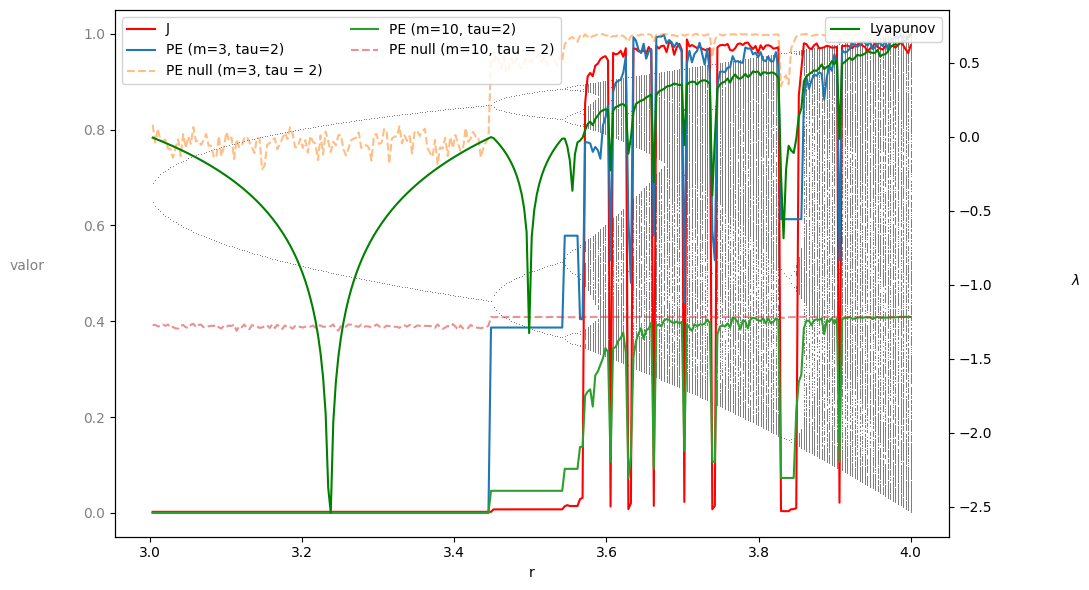

In [12]:
import numpy as np
import matplotlib.pyplot as plt

# Debes tener definida en tu entorno:
# permutation_entropy(arr, m=3, tau=1, base=np.e)

@njit
def logistic_map(r, x):
    return r * x * (1.0 - x)

@njit
def logistic_orbit(r, x0=0.6, n_discard=2000, n_keep=2000):
    """Genera una órbita del mapa logístico para un r dado."""
    x = x0
    for _ in range(n_discard):
        x = logistic_map(r, x) 
    xs = np.empty(n_keep, dtype=float)
    for i in range(n_keep):
        x = logistic_map(r, x)
        xs[i] = x
    return xs

def plot_logistic_pe_vs_r_memory_safe(
    m_values,
    permutar,        # PE / log(m!) para [0,1]
    num_r,              # ↓ Si falta memoria, baja este valor
    n_discard,
    n_keep_pe,         # ↓ Longitud de órbita SOLO para PE (evita n grandes)
    tau,
    r_min=3.0, r_max=4.0,
    x0=0.61
):
    """
    Grafica PE(r) para varios m (una curva por m) y, opcionalmente, el diagrama
    de bifurcación de forma segura en memoria (sin acumular millones de puntos).
    """
    rs = np.linspace(r_min, r_max, num_r)
    pe_curves = {m: np.empty(num_r, dtype=float) for m in m_values}
    pe_curves_null = {m: np.empty(num_r, dtype=float) for m in m_values}
    periodos_logistic = create_periodos_logistic()
    # --- Cálculo de PE por r (sin acumular nada más) ---
    for idx, r in enumerate(rs):
        xs = logistic_orbit(r, x0=x0, n_discard=n_discard, n_keep=n_keep_pe) 
        for i,m in enumerate(m_values):
            tau = tau
            if r == 3.0:
                pe_curves[m][idx] = np.nan
                pe_curves_null[m][idx] = np.nan
                continue
            # xs = remove_consecutive_duplicates(xs, tolerance=1e-10)
            if periodos_logistic[idx-1] != "Caos":
                patron = np.arange(periodos_logistic[idx-1])
                xs = np.tile(patron, n_keep_pe//periodos_logistic[idx-1])
            pe = permutation_entropy(xs, m=m, tau=tau)
            if permutar[i]:
                pe_null = permutation_entropy(np.random.permutation(xs), m=m, tau=tau)
            # plt.hist(probs, bins=30)
            # plt.title(f'Histograma de probabilidades para m={m}, tau={tau}')
            # plt.xlabel('Probabilidad')
            # plt.ylabel('Frecuencia')
            # plt.show()
            pe_curves_null[m][idx] = pe_null
            pe_curves[m][idx] = pe

    # --- Plot ---
    r_values = []
    orbit_values = []
    
    for r in np.linspace(r_min, r_max, num_r):
        if r == 3.0:
            continue
        x = 0.6
        for _ in range(1000): # Converger
            # x = np.clip(x, 0.0, 1.0)
            x = logistic_map(r, x) #+ generar_uniforme_centrada(1, 1e-6)[0]
        for _ in range(1000):
            # x = np.clip(x, 0.0, 1.0)
            x = logistic_map(r, x) #+ generar_uniforme_centrada(1, 1e-6)[0]
            r_values.append(r)
            orbit_values.append(x)
        # if r > 3.2 and r < 3.25:
        #     plt.plot(orbit_values[:100])
        #     plt.show()
    fig, ax1 = plt.subplots(figsize=(11,6))

    # Diagrama de bifurcación sin listas gigantes: se dibuja por chunks
    ax1.plot(r_values, orbit_values, ',', alpha=1.0, rasterized=True, color='gray')
    J = np.load(r"data/J_OG_muchosdatos.npy")
    lyap = np.load(r"data/lyapunov_continuo.npy")
    ax1.plot(rs[1:], J, alpha=1.0, rasterized=True, color='red', label='J')
    ax1.set_xlabel('r')
    ax1.set_ylabel('valor', rotation=0, labelpad=40, color='gray')
    ax1.tick_params(axis='y', labelcolor='gray')

    # Segundo eje: PE
    ax2 = ax1.twinx()
    for i,m in enumerate(m_values):
        ax1.plot(rs, pe_curves[m], label=f'PE (m={m}, tau={tau})')
        if permutar[i]:
            ax1.plot(rs, pe_curves_null[m], '--', label=f'PE null (m={m}, tau = {tau})', alpha=0.5)
    ylab = r'$\lambda$'
    ax2.set_ylabel(ylab, rotation=0, labelpad=60)
    ax2.plot(rs[1:], lyap, alpha=1.0, rasterized=True, color='green', label='Lyapunov')
    ax2.tick_params(axis='y')
    ax2.legend(loc='upper right', ncol=2, framealpha=0.85)
    ax1.legend(loc='upper left', ncol=2, framealpha=0.85)

    plt.tight_layout()
    plt.show()

    return rs, pe_curves
    
# Ejemplo típico (ajusta si necesitas):
rs, pe_curves = plot_logistic_pe_vs_r_memory_safe(
    m_values=[3,10],
    permutar=[True, True],        # PE / log(m!) para [0,1]
    num_r=300,              # ↓ Si falta memoria, baja este valor
    n_discard = 4000,
    n_keep_pe = 500,         # ↓ Longitud de órbita SOLO para PE (evita n grandes)
    tau = 2,
)


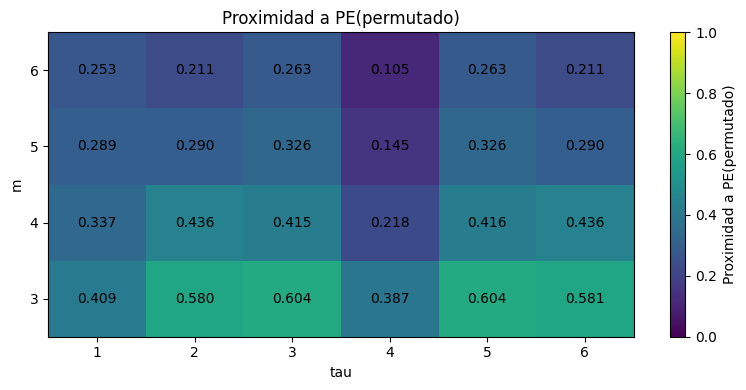

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from typing import Sequence, Callable, Optional, Tuple, List

def heatmap_pe_vs_surrogate(
    array: np.ndarray,
    m_values: Sequence[int],
    tau_values: Sequence[int],
    pe_func: Callable[[np.ndarray, int, int], float],
    n_surrogates: int = 5,
    panels: Tuple[str, ...] = ("proximity",),  # opciones: "proximity", "pe_perm", "absdiff"
    annotate: bool = True,
    figsize: Tuple[int, int] = (8, 4),
    savepath: Optional[str] = None,
    rng: Optional[np.random.Generator] = None,
):
    """
    Genera heatmaps comparando PE observado vs PE de surrogates permutados.

    Color por panel:    Si PE = 2*PE_perm entonces proximitdad = 0
                        Si PE = 0 entonces proximitdad = 0
      - "proximity": 1 - |PE - PE_perm| / PE_perm  (anota PE)
      - "pe_perm":   PE_perm                                 (anota PE_perm)
      - "absdiff":   |PE - PE_perm|                          (anota |PE - PE_perm|)
    Devuelve un dict con matrices: {"PE": pe_mat, "PE_perm": pe_perm_mat, "proximity": prox_mat, "absdiff": diff_mat}
    """
    if rng is None:
        rng = np.random.default_rng()

    array = np.asarray(array, dtype=float)
    n = len(array)
    M, T = len(m_values), len(tau_values)

    # Matrices
    pe_mat      = np.full((M, T), np.nan)
    pe_perm_mat = np.full((M, T), np.nan)
    prox_mat    = np.full((M, T), np.nan)
    diff_mat    = np.full((M, T), np.nan)

    # Helpers
    def surrogate_pe(m: int, tau: int) -> float:
        vals = []
        for _ in range(max(1, n_surrogates)):
            perm = rng.permutation(array)
            vals.append(pe_func(perm, m=m, tau=tau))
        return float(np.nanmean(vals))

    eps = 1e-12
    for i, m in enumerate(m_values):
        for j, tau in enumerate(tau_values):
            # Validez de ventana
            if m < 2 or tau < 1 or n - (m - 1) * tau <= 0:
                continue
            pe = pe_func(array, m=m, tau=tau)
            pe_surr = surrogate_pe(m, tau)
            pe_mat[i, j] = pe
            pe_perm_mat[i, j] = pe_surr
            diff = abs(pe - pe_surr)
            diff_mat[i, j] = diff
            prox_mat[i, j] = 1.0 - diff / max(pe_surr, eps)
            prox_mat[i, j] = np.clip(prox_mat[i, j], 0.0, 1.0)

    # --- Plot ---
    panel_list: List[str] = list(panels)
    n_cols = len(panel_list)
    fig, axes = plt.subplots(1, n_cols, figsize=figsize if n_cols == 1 else (figsize[0]*n_cols, figsize[1]))
    if n_cols == 1:
        axes = [axes]

    # Etiquetas
    xticks = list(range(T))
    yticks = list(range(M))
    xtlabs = [str(t) for t in tau_values]
    ytlabs = [str(m) for m in m_values]

    for ax, kind in zip(axes, panel_list):
        if kind == "proximity":
            data = prox_mat; title = "Proximidad a PE(permutado)"; annot_mat = pe_mat; annot_fmt = "{:.3f}"
        elif kind == "pe_perm":
            data = pe_perm_mat; title = "PE del surrogate (promedio)"; annot_mat = pe_perm_mat; annot_fmt = "{:.3f}"
        elif kind == "absdiff":
            data = diff_mat; title = "|PE − PE(permutado)|"; annot_mat = diff_mat; annot_fmt = "{:.3g}"
        else:
            raise ValueError(f"Panel desconocido: {kind}")

        im = ax.imshow(data, origin="lower", aspect="auto",vmin=0.0, vmax=1.0)
        cbar = plt.colorbar(im, ax=ax)
        cbar.set_label(title)

        ax.set_xticks(xticks); ax.set_xticklabels(xtlabs)
        ax.set_yticks(yticks); ax.set_yticklabels(ytlabs)
        ax.set_xlabel("tau"); ax.set_ylabel("m"); ax.set_title(title)

        if annotate:
            for i in range(M):
                for j in range(T):
                    v = annot_mat[i, j]
                    if np.isfinite(v):
                        ax.text(j, i, annot_fmt.format(v), ha="center", va="center")

    plt.tight_layout()
    if savepath is not None:
        plt.savefig(savepath, dpi=150, bbox_inches="tight")

    return {
        "PE": pe_mat,
        "PE_perm": pe_perm_mat,
        "proximity": prox_mat,
        "absdiff": diff_mat,
    }


Periodo_3 =  3.82943143812709
Periodo_2 = 3.2
Periodo_4 =  3.5
Periodo_5 =  3.7391304347826084
Periodo_8 =  3.548494983277592
Periodo_16 =  3.568561872909699
Punto_critico  = 3.5699431086217244
Caos =  4.0
Menor_caos =  3.86

patron = np.arange(8)
xs = np.tile(patron, 500//3)
# xs = logistic_orbit(Caos,0.6,n_discard=2000,n_keep=500)

_ = heatmap_pe_vs_surrogate(xs, [3,4,5,6], [1,2,3,4,5,6], permutation_entropy,
                            n_surrogates=10, panels=("proximity",), annotate=True)

In [94]:
af = np.load(r'data/regimen_caotico.npy')
periodos = create_periodos_logistic()
print(periodos)

[2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 8, 8, 8, 8, 8, 8, 16, 16, 'Caos', 'Caos', 'Caos', 'Caos', 'Caos', 'Caos', 'Caos', 'Caos', 'Caos', 'Caos', 10, 'Caos', 'Caos', 'Caos', 'Caos', 'Caos', 'Caos', 6, 12, 'Caos', 'Caos', 'Caos', 'Caos', 'Caos', 'Caos', 'Caos', 'Caos', 8, 'Caos', 'Caos', 'Caos', 'Caos', 'Caos', 'Caos', 'Caos', 'Caos', 'Caos', 'Caos', 'Caos', 14, 'Caos', 'Caos', 'Caos', 'Caos', 'Caos', 'Caos', 'Caos', 'Caos', 'Caos', 'Caos', 5, 10, 'Caos', 'Caos', 'Caos', 'Caos', 'Caos', 'Caos', 'Caos', 'Caos', 'Caos', 'Caos', 'Caos', 'Caos', 'Caos'

In [4]:
J_min = np.load('data/J_minus_continuo.npy')
J_min[1,np.where(J_min[0,:] == 27770//2)]

array([[0.98316834]])

2
Interpolación


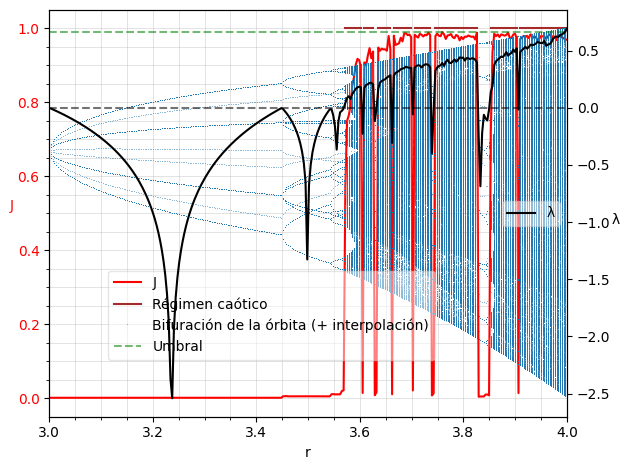

Correlación de Spearman J_OG_lyapunov: 0.6093165217200119
Correlación de Spearman J_interp_lyapunov: 0.7398817843558461
Correlación de Spearman caotico J_interp_lyapunov: 0.6390904960611208
Correlación de Spearman: 0.9984559286383959


In [ ]:
def logistic_map(r, x):
    return r * x * (1 - x)
# 3000 y 2000, 1000000 y 35000, 3000 y 500
def plot_orbit_diagram(num_interp,interpolacion,cantidad,interp_type,graficar=True, r_min = 3.0, r_max = 4.0, num_points_per_r=300,
 num_iterations_discard=1000, num_iterations_display=2000):
    
    if cantidad == 'muchosdatos':
        J_continuo = np.load('data/J_OG_muchosdatos.npy')
    if cantidad == 'pocosdatos':
        J_continuo = np.load('data/j_logistic_continuo.npy')
    if interpolacion == "si":
        print("Interpolación")

    r_values = []
    orbit_values = []
    
    for r in np.linspace(r_min, r_max, num_points_per_r):
        if r == 3.0:
            continue
        x = 0.6
        for _ in range(num_iterations_discard): # Converger
            # x = np.clip(x, 0.0, 1.0)
            x = logistic_map(r, x) #+ generar_uniforme_centrada(1, 1e-6)[0]
        for _ in range(num_iterations_display):
            # x = np.clip(x, 0.0, 1.0)
            x = logistic_map(r, x) #+ generar_uniforme_centrada(1, 1e-6)[0]
            r_values.append(r)
            orbit_values.append(x)
        
    #A partir de aqui, orbita continua de logistica completada
        
    a = 0
    J_values=[]
    J_index=[]
    caotico = np.load('data/regimen_caotico.npy')
    lyapunov_values = []
    periodos_log    istic = create_periodos_logistic()
    b=0
    
    r_values_interp = []
    orbit_values_interp = np.array([])
    for i in range(0, len(r_values) - 1):
        if r_values[i] != r_values[i+1]:
            r_single_orbit = orbit_values[a:i+1]
            # if periodos_logistic[b] != "Caos":
            #     r_single_orbit = r_single_orbit[:2000] # 3.57190635451505 171
            a = i+1

            if interpolacion == 'si':
                x = np.arange(len(r_single_orbit))
                data_interp = r_single_orbit #+ generar_uniforme_centrada(len(r_single_orbit),1e-6)
                x_new, data_interp = interpolador(data_interp, interp_type, num_interp)
                # data_interp = interpolador_constante(r_single_orbit)
                # data_interp = interpolador_estocastico(data_interp, 3)
                r_values_interp = r_values_interp + [r_values[i]]*len(data_interp)
                orbit_values_interp = np.concatenate((orbit_values_interp, data_interp))

                r_single_orbit = data_interp

            lyapunov = lyapunov_exponent_from_orbit(r_single_orbit, r_values[i])
            lyapunov_values.append(lyapunov)
            # J = J_univariante(r_single_orbit, 1, False)
            # J_values.append(J)
            J_index.append(r_values[i])
            b += 1

    #ultimo valor de r
    lyapunov = lyapunov_exponent_from_orbit(orbit_values[a:], r_values[len(r_values) - 1])  
    lyapunov_values.append(lyapunov)
    r_single_orbit = orbit_values[a:]
    if interpolacion == 'si':
        # r_single_orbit = remove_consecutive_duplicates(r_single_orbit)
        data_interp = r_single_orbit #+ generar_uniforme_centrada(len(r_single_orbit), 1e-6)
        x = np.arange(len(r_single_orbit))
        x_new, data_interp = interpolador(data_interp, interp_type, num_interp)
        # data_interp = interpolador_constante(r_single_orbit)
        # data_interp = interpolador_estocastico(r_single_orbit, 3)
        r_values_interp = r_values_interp + [r_values[i]]*len(data_interp)
        orbit_values_interp = np.concatenate((orbit_values_interp, data_interp))
        r_single_orbit = data_interp
    
    # J = J_univariante(r_single_orbit, 1, False)
    # J_values.append(J)
    J_index.append(r_values[len(r_values) - 1])
    """A partir de aqui, lyapunob y J fueron calculados"""
    if num == 10 or num == 15:
        J_values = np.load('data/interpolación_'+interp_type+'/datos/J_interp_z'+str(num_interp)+'_'+interp_type+'_'+str(cantidad)+'.npy')
    else:
        J_values = np.load('data/interpolación_'+interp_type+'/datos/J_interp_'+str(num_interp)+'_'+interp_type+'_'+str(cantidad)+'.npy')
    caotico = np.where(np.array(J_continuo) > 0.2, 1, np.nan)

    
    if graficar == True:
        fig, ax1 = plt.subplots()#figsize=(10,6)
    
        ax1.plot(J_index, J_values, color='red', label='J' , alpha = 1)
        ax1.plot(J_index, np.array(caotico), color ='brown',linestyle='-', label = 'Régimen caótico')
        # ax1.plot(J_index, J_continuo, 'red',label='J (Original)', alpha = 0.3)
        if interpolacion == "si":
            ax1.plot(r_values_interp, orbit_values_interp, ',', label=f'Bifuración de la órbita (+ interpolación)', alpha=0.5)
        else: 
            ax1.plot(r_values, orbit_values, ',', label='Bifurcación de la órbita', alpha=1)
                            
        ax1.set_xlabel('r') #.9873
        if cantidad == 'muchosdatos':
            num_iterations_display = 35000
        Namano = ((num_iterations_display-1)*num_interp + num_iterations_display)//2
        if Namano > 13920:
            umbral = 0.99
        else:
            umbral = np.load('data/J_minus_continuo.npy')[1,np.where(np.load('data/J_minus_continuo.npy')[0,:] == Namano)]
        ax1.axhline(y = umbral, color='green', linestyle='--', alpha =0.55,label='Umbral') # y = 0.9873 y = 0.94 y = 0.88
        ax1.set_ylabel('J', color='r', rotation = 360)
        ax1.tick_params(axis='y', labelcolor='r')
        ax1.legend(loc='center left', bbox_to_anchor=(0.1, 0.25), framealpha=0.5)
        ax1.set_xlim(3.0, 4.0)

        
        major_ticks_x = np.linspace(3.0, 4.0, 6)  # 0.0, 0.2, ..., 1.0
        minor_ticks_x = np.linspace(3.0, 4.0, 21)  # Ticks secundarios

        major_ticks_y = np.linspace(0, 1, 6)  # -1, -0.5, 0, 0.5, 1.0
        minor_ticks_y = np.linspace(0, 1, 21)  # Ticks secundarios

        # Configurar los ticks del eje X
        plt.xticks(major_ticks_x)  # Solo etiquetar los ticks principales
        plt.gca().set_xticks(minor_ticks_x, minor=True)  # Agregar ticks menores sin etiquetas

        # Configurar los ticks del eje Y
        plt.yticks(major_ticks_y)  # Solo etiquetar los ticks principales
        plt.gca().set_yticks(minor_ticks_y, minor=True)  # Agregar ticks menores sin etiquetas

        # Activar la cuadrícula
        plt.grid(which='major', linestyle='-', linewidth=0.5, alpha=0.5)  # Para ticks principales
        plt.grid(which='minor', linestyle='-', linewidth=0.5, alpha=0.5)         

        lyapunov_continuo = np.load('data/lyapunov_continuo.npy')
        if True:
            ax2 = ax1.twinx()
            ax2.axhline(y=0, color='black', linestyle='--', alpha =0.55)
            ax2.plot(J_index, lyapunov_continuo, 'black', label = 'λ')
            ax2.set_ylabel('λ', color='black', rotation = 360)
            ax2.tick_params(axis='y', labelcolor='black')
            ax2.legend(loc='center right',framealpha=0.5)
            # ax2.set_xlim(3.571906, 4.0)
        
        fig.tight_layout()  
        plt.show()
        caotico = np.array(caotico)
        J_values = np.array(J_values)
        lyapunov_values = np.array(lyapunov_values)
        correlacion3, p_valor = pearsonr(J_values, lyapunov_continuo)
        correlacion, p_valor = pearsonr(J_values[~np.isnan(caotico)], lyapunov_continuo[~np.isnan(caotico)])
        correlacion2, p_valor2 = pearsonr(J_continuo[~np.isnan(caotico)], lyapunov_continuo[~np.isnan(caotico)])
        print(f'Correlación de Spearman J_OG_lyapunov: {correlacion2}')
        print(f'Correlación de Spearman J_interp_lyapunov: {correlacion3}')
        print(f'Correlación de Spearman caotico J_interp_lyapunov: {correlacion}')

    return J_values, lyapunov_continuo, caotico


J_continuo = np.load('data/J_OG_muchosdatos.npy')
# J_continuo = np.load('logistic_map/j_logistic_continuo.npy')
for num in [2]:
    print(num)
    J_values, lyapunov_continuo, caotico = plot_orbit_diagram(num,'si','muchosdatos','herm')

# Calcular correlación de Spearman
correlacion, p_valor = pearsonr(J_values, J_continuo)

print(f'Correlación de Spearman: {correlacion}')


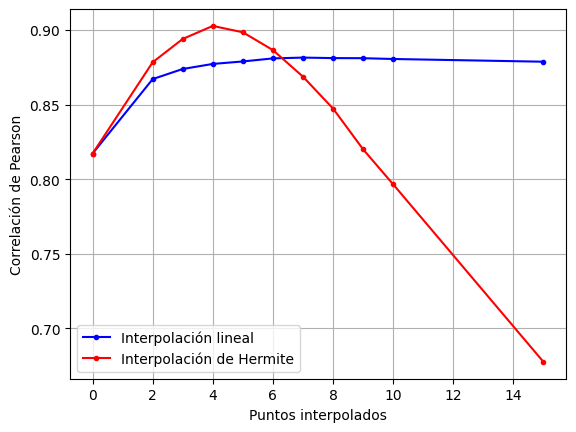

In [ ]:
def graficar_correlaciones_interpolacion(cantidad_datos, zona, lyapunov_continuo = np.load('logistic_map/lyapunov_continuo.npy') ,caotico=np.load('logistic_map/regimen_caotico.npy')):
    """
    Genera gráficas de correlación entre índice J y exponente de Lyapunov para distintas interpolaciones.

    Parámetros:
    -----------
    lyapunov_continuo : array
        Array de exponentes de Lyapunov (ya cargado previamente).
    cantidad_datos : str
        'pocos', 'muypocos' o 'muchos'
    zona : str
        'caos_regular' o 'caos'
    """

    corrs = {'corrs1': [], 'corrs2': []}
    etiquetas_x = [0, 2, 3, 4, 5, 6, 7, 8, 9, 10, 15]

    for tipo_interp, corr_list in zip(['lineal', 'herm'], corrs.keys()):
        carpeta = f'data/interpolación_{tipo_interp}/datos'
        archivos_en_carpeta = os.listdir(carpeta)
        for archivo in archivos_en_carpeta:
            if cantidad_datos == 'pocos' and 'pocosdatos.npy' in archivo and not 'muypocosdatos.npy' in archivo:
                pass
            elif cantidad_datos == 'muypocos' and 'muypocosdatos.npy' in archivo:
                pass
            elif cantidad_datos == 'muchos' and 'muchosdatos.npy' in archivo:
                pass
            else:
                continue

            Js = np.load(os.path.join(carpeta, archivo))

            if zona == 'caos_regular':
                correlacion, _ = pearsonr(Js[171:], lyapunov_continuo[171:])
            elif zona == 'caos':
                mask = ~np.isnan(caotico)
                correlacion, _ = pearsonr(Js[mask], lyapunov_continuo[mask])
            else:
                raise ValueError("zona debe ser 'caos_regular' o 'caos'")

            corrs[corr_list].append(correlacion)

    # Graficar
    plt.plot(etiquetas_x, corrs['corrs1'], label='Interpolación lineal', color='blue', marker='.')
    plt.plot(etiquetas_x, corrs['corrs2'], label='Interpolación de Hermite', color='red', marker='.')
    plt.xlabel('Puntos interpolados')
    plt.ylabel('Correlación de Pearson')
    plt.legend()
    plt.grid()
    plt.show()

graficar_correlaciones_interpolacion('pocos','caos_regular',lyapunov_continuo,caotico)

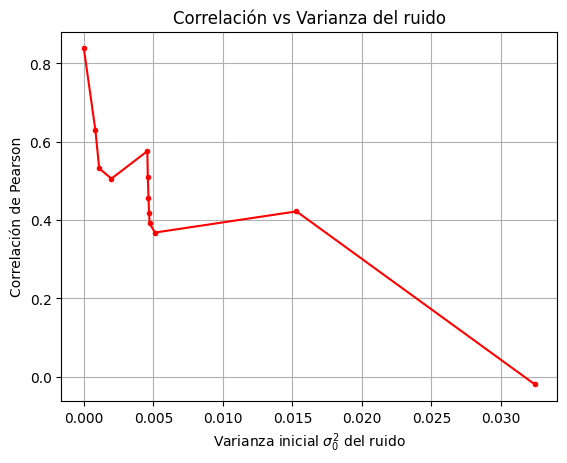

In [ ]:
def graficar_correlacion_vs_varianza(carpeta):
    """
    Calcula y grafica correlación de Pearson entre varianza y J, ordenando por varianza.
    
    Parámetros:
    -----------
    carpeta : str
        Ruta donde están los archivos de varianza y J.
    """
    varianzas_todos = []
    correlaciones_todos = []
    etiquetas_ruido = []

    archivos_en_carpeta = os.listdir(carpeta)

    for archivo in archivos_en_carpeta:
        if 'J_por_ruido' in archivo:
            ruido = archivo[12:]  # Extrae el sufijo del nombre de archivo
        else:
            continue

        varianza = np.mean(np.load(os.path.join(carpeta, f'varianza_por_ruido_{ruido}')), axis=0)
        J = np.mean(np.load(os.path.join(carpeta, f'J_por_ruido_{ruido}')), axis=0)

        mask = ~np.isnan(varianza) & ~np.isnan(J)
        if np.any(mask):
            correlacion, _ = pearsonr(varianza[mask], J[mask])
            varianza_media = np.mean(varianza[mask])
            varianzas_todos.append(varianza_media)
            correlaciones_todos.append(correlacion)
            etiquetas_ruido.append(ruido)

    # Ordenar por varianza
    orden = np.argsort(varianzas_todos)
    varianzas_ordenadas = np.array(varianzas_todos)[orden]
    correlaciones_ordenadas = np.array(correlaciones_todos)[orden]

    # Graficar
    plt.figure()
    plt.plot(varianzas_ordenadas, correlaciones_ordenadas, 'r.-')
    plt.xlabel(r'Varianza inicial $\sigma_0^2$ del ruido')
    plt.ylabel('Correlación de Pearson')
    plt.grid(True)
    plt.title('Correlación vs Varianza del ruido')
    plt.show()

# Ejemplo de uso:
graficar_correlacion_vs_varianza('data/ruidos_promedios_iterado')


Dinámica simbólica


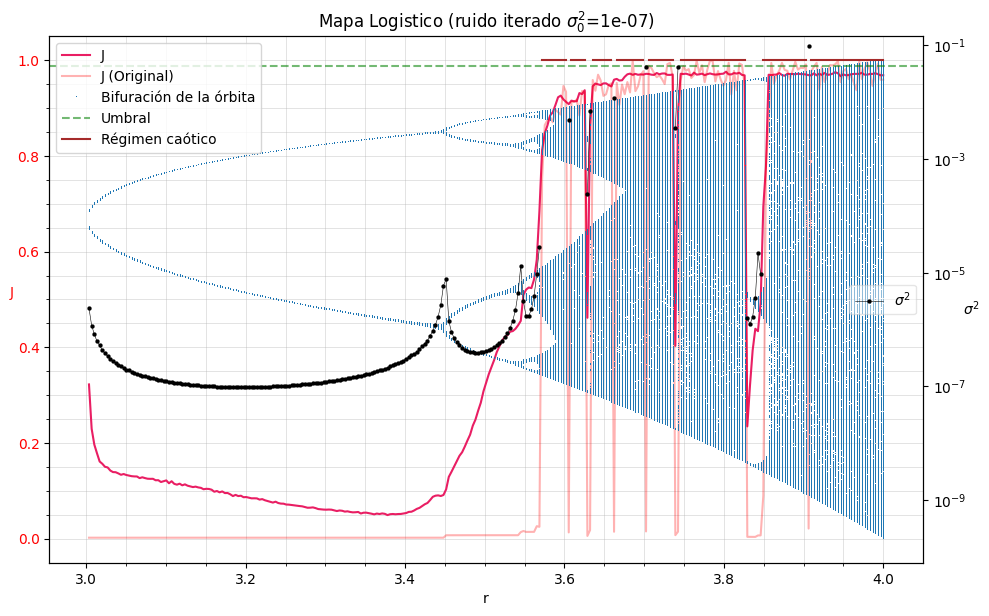

Correlación J-Jruido: 0.8942484220635515
Correlación de Spearman: 0.8942484220635515


In [ ]:
"""interpolacion despues de dinamica simbolica"""
"""CON VARIANZA FUNCIONAL"""

def logistic_map(r, x):
    return r * x * (1 - x)

def plot_orbit_diagram(ruido,num_partitions,discreto,interpolacion, size,graficar, r_min = 3.0, r_max = 4.0, num_points_per_r=300,
 num_iterations_discard=4000, num_iterations_display=2000):
    if discreto == "no" and interpolacion == "si": 
        print("Haz seleccionado interpolación a los datos continuos, eso no tiene caso")
        return 1,2

    if interpolacion == "si":
        print("Interpolación")
    
    r_values = []
    orbit_values = []
    
    for r in np.linspace(r_min, r_max, num_points_per_r):
        if r == 3.0:
            continue
        x = 0.6
        ruidos = [1e-10,1e-8,1e-7,1e-4,1e-5,1e-6]
        colores = ['gray','#2ECC71','purple','#E91E63','#1ABC9C', '#FFD700']

        for _ in range(num_iterations_discard): # Converger
            x = np.clip(x, 0.0, 1.0)
            x = logistic_map(r, x) + generar_uniforme_centrada(1, ruido)[0]
        for _ in range(num_iterations_display):
            x = np.clip(x, 0.0, 1.0)
            x = logistic_map(r, x) + generar_uniforme_centrada(1, ruido)[0]
            r_values.append(r)
            orbit_values.append(x)
        
    #A partir de aqui, orbita continua de logistica completada
    if discreto == "si":
        print('Dinámica simbólica')
        # orbit_values = discretizar(orbit_values, num_partitions )
        
    a = 0
    b = 0
    J_values=[]
    J_index=[]
    # caotico = []
    varianzas=[]
    lyapunov_values = []
    
    r_values_interp = []
    orbit_values_interp = np.array([])
    ti, to = True, True
    for i in range(0, len(r_values) - 1):
        if r_values[i] != r_values[i+1]:
            # print(r_values[i])
            r_single_orbit = orbit_values[a:i+1]
            a = i+1
            if interpolacion == 'si':
                x = np.arange(len(r_single_orbit))
                x_new, data_interp = interpolador(r_single_orbit, 'lineal', 15)
                # data_interp = interpolador_estocastico(data_interp, 3)
                # data_interp = r_single_orbit
                # random_array = generar_uniforme_centrada(num_iterations_display,ruido)
                # data_interp = data_interp + random_array
                r_values_interp = r_values_interp + [r_values[i]]*len(data_interp)
                orbit_values_interp = np.concatenate((orbit_values_interp, data_interp))

                r_single_orbit = data_interp
            var = var_per_state(r_single_orbit, periodos_logistic[b])
            if var == "Caos":
                varianzas.append(np.nan)
            else:
                varianzas.append( np.sum(np.array(var))/periodos_logistic[b])
            # lyapunov = lyapunov_exponent_from_orbit(r_single_orbit, r_values[i])
            # lyapunov_values.append(lyapunov)
            # J, angulos = J_univariante(r_single_orbit, 1, False)
            # J_values.append(J)
            J_index.append(r_values[i])
            b += 1


    
    #ultimo valor de r
    lyapunov = lyapunov_exponent_from_orbit(orbit_values[a:], r_values[len(r_values) - 1])  
    lyapunov_values.append(lyapunov)
    r_single_orbit = orbit_values[a:]
    if interpolacion == 'si':
        x = np.arange(len(orbit_values[a:]))
        x_new, data_interp = interpolador(orbit_values[a:], 'lineal', 15)
        # data_interp = interpolador_estocastico(data_interp, 3)
        # data_interp = orbit_values[a:]
        # data_interp = data_interp + random_array
        r_values_interp = r_values_interp + [r_values[i]]*len(data_interp)
        orbit_values_interp = np.concatenate((orbit_values_interp, data_interp))
        r_single_orbit = data_interp
    
    J = J_univariante(r_single_orbit, 1, False)[0]
    J_values.append(J)
    varianzas.append(np.nan)
    J_index.append(r_values[len(r_values) - 1])
    caotico = np.load('data/regimen_caotico.npy')
    J_values = np.load('data/ruidos_promedios_iterado/J_por_ruido_'+str(ruido)+'.npy')
    varianzas = np.load('data/ruidos_promedios_iterado/varianza_por_ruido_'+str(ruido)+'.npy')
    J_values = np.mean(J_values, axis=0)
    varianzas = np.mean(varianzas, axis = 0)

    #A partir de aqui, lyapunob y J fueron calculados
    # J_continuo = np.load('data\J_OG_muchosdatos.npy')
    J_continuo = np.load('data/j_logistic_continuo.npy')

    if graficar == True:
        fig, ax1 = plt.subplots(figsize=(10,6))
        
        if discreto == "no":
            color = "red"
        elif discreto == "si":
            color = '#E91E63'
    
        ax1.plot(J_index, J_values, color=color, label='J' , alpha = 1)
        if discreto == "si":
            ax1.plot(J_index, J_continuo, 'red',label='J (Original)', alpha = 0.3)
            if interpolacion == "si":
                ax1.plot(r_values_interp, orbit_values_interp, ',', label=f'Bifuración de la órbita (+ ruido aditivo)', alpha=0.5)
            else: 
                ax1.plot(r_values, orbit_values, ',', label=f'Bifuración de la órbita', alpha=1)
        if discreto == "no":
            ax1.plot(r_values, orbit_values, ',', label='Bifurcación de la órbita', alpha=1)
        ax1.set_xlabel('r')
        ax1.set_ylabel('J', color='r', rotation = 360)
        ax1.tick_params(axis='y', labelcolor='r')
        # ax1.set_ylim(0,1)
        ax1.axhline(y=0.9873, color='green', linestyle='--', alpha =0.55,label='Umbral')
        ax1.plot(J_index, np.array(caotico), color ='brown',linestyle='-', label = 'Régimen caótico')
        ax1.legend(loc = 'upper left')
        major_ticks_x = np.linspace(3, 4, 6)  # 0.0, 0.2, ..., 1.0
        minor_ticks_x = np.linspace(3, 4, 21)  # Ticks secundarios

        major_ticks_y = np.linspace(0, 1, 6)  # -1, -0.5, 0, 0.5, 1.0
        minor_ticks_y = np.linspace(0, 1, 21)  # Ticks secundarios

        # Configurar los ticks del eje X en ax1
        ax1.set_xticks(major_ticks_x)  # Solo etiquetar los ticks principales
        ax1.set_xticks(minor_ticks_x, minor=True)  # Agregar ticks menores sin etiquetas

        # Configurar los ticks del eje Y en ax1
        ax1.set_yticks(major_ticks_y)  # Solo etiquetar los ticks principales
        ax1.set_yticks(minor_ticks_y, minor=True)  # Agregar ticks menores sin etiquetas

        # Activar la cuadrícula en ax1
        ax1.grid(which='major', linestyle='-', linewidth=0.5, alpha=0.5)  # Para ticks principales
        ax1.grid(which='minor', linestyle='-', linewidth=0.5, alpha=0.5)  # Para ticks menores      

        if discreto == "no":
            ax2 = ax1.twinx()
            ax2.axhline(y=0, color='black', linestyle='--', alpha =0.55)
            ax2.plot(J_index, lyapunov_values, 'black', label = 'λ')
            ax2.set_ylabel('λ', color='black', rotation = 360)
            ax2.tick_params(axis='y', labelcolor='black')
            ax2.legend(loc='center right',framealpha=0.5)

        if discreto == "si" and True:
            ax2 = ax1.twinx() #[round(var*3, 8) if not np.isnan(var) else np.nan for var in varianzas]
            ax2.plot(J_index, varianzas, color ='black',ls='-',lw=0.4,marker='.',mew=0.1, label = r'$\sigma^2$')
            ax2.set_ylabel(r'$\sigma^2$', color='black', rotation = 360)
            # ax2.set_ylabel('P', color='black', rotation = 360)
            ax2.tick_params(axis='y', labelcolor='black')
            ax2.legend(loc='center right',framealpha=0.5)
            ######################
            ax2.set_yscale('log')
            if 1.5*max(varianzas) > 0.1:
                ax2.set_ylim(0.8e-10, 1.5*max(varianzas))
            else:
                ax2.set_ylim(0.8e-10, 0.1)
            # ax2.set_xlim(3.7,3.8)
            # ax2.set_ylim(0,np.max(varianzas[:170]))
            #####################

        fig.tight_layout()  
        # plt.title(f'Logistic Map (Discret ={discreto}, interp= {interpolacion})')
        # plt.title(f'Mapa Logístico con discretización en el eje y ({num_partitions} Particiones)')
        plt.title(r'Mapa Logistico (ruido iterado $\sigma_0^2$='+f'{ruido})')
        # plt.title('Mapa Logístico')
        # fig.savefig("logistic_map\logistic_ruido_iterado\logistic_"+str(ruido)+".png")
        plt.show()

        # plt.plot(derivadas_x,derivadas_y,',',color='red')
        # plt.ylim(-4,2)
        # plt.show()
    correlacion, p_valor = spearmanr(J_values, J_continuo)
    print(f'Correlación J-Jruido: {correlacion}')
    # correlacion, p_valor = spearmanr(J_values[~np.isnan(varianzas)], varianzas[~np.isnan(varianzas)])
    # print(f'Correlación de Jruido-varianza: {correlacion}')
    # np.save("varianzas_OG.npy", np.array(varianzas, dtype=object))
    if interpolacion == 'no':
        return J_index, J_values, r_values, orbit_values, lyapunov_values
    else:
        return J_index, J_values, r_values_interp, orbit_values_interp, lyapunov_values 


# J_continuo = np.load('logistic_map\J_OG_muchosdatos.npy')
J_continuo = np.load('data/j_logistic_continuo.npy')

# for ruido in [1e-10,1e-8, 1e-7,1e-6,1e-5,1e-4,1e-5,2e-5,3e-5,4e-5,5e-5,1e-3,1e-2]:
for ruido in [1e-7]:
    J_index, J_values, r_values, orbit_values, lyapunov_values = plot_orbit_diagram(ruido,15,"si","no", 20 ,True)
# J_index, J_values, r_values, orbit_values, lyapunov_values_continuo = plot_orbit_diagram(50,"no", "no", 20 ,True)


# Calcular correlación de Spearman
correlacion, p_valor = spearmanr(J_values, J_continuo)

print(f'Correlación de Spearman: {correlacion}')

Interpolación
Dinámica simbólica
Dinámica simbólica
Dinámica simbólica
Dinámica simbólica
Dinámica simbólica
Dinámica simbólica
Dinámica simbólica
Dinámica simbólica
Dinámica simbólica
Dinámica simbólica
Dinámica simbólica
Dinámica simbólica
Dinámica simbólica
Dinámica simbólica
Dinámica simbólica
Dinámica simbólica
Dinámica simbólica
Dinámica simbólica
Dinámica simbólica
Dinámica simbólica
Dinámica simbólica
Dinámica simbólica
Dinámica simbólica
Dinámica simbólica
Dinámica simbólica
Dinámica simbólica
Dinámica simbólica
Dinámica simbólica
Dinámica simbólica
Dinámica simbólica
Dinámica simbólica
Dinámica simbólica
Dinámica simbólica
Dinámica simbólica
Dinámica simbólica
Dinámica simbólica
Dinámica simbólica
Dinámica simbólica
Dinámica simbólica
Dinámica simbólica
Dinámica simbólica
Dinámica simbólica
Dinámica simbólica
Dinámica simbólica
Dinámica simbólica
Dinámica simbólica
Dinámica simbólica
Dinámica simbólica
Dinámica simbólica
Dinámica simbólica
Dinámica simbólica
Dinámica simbólic

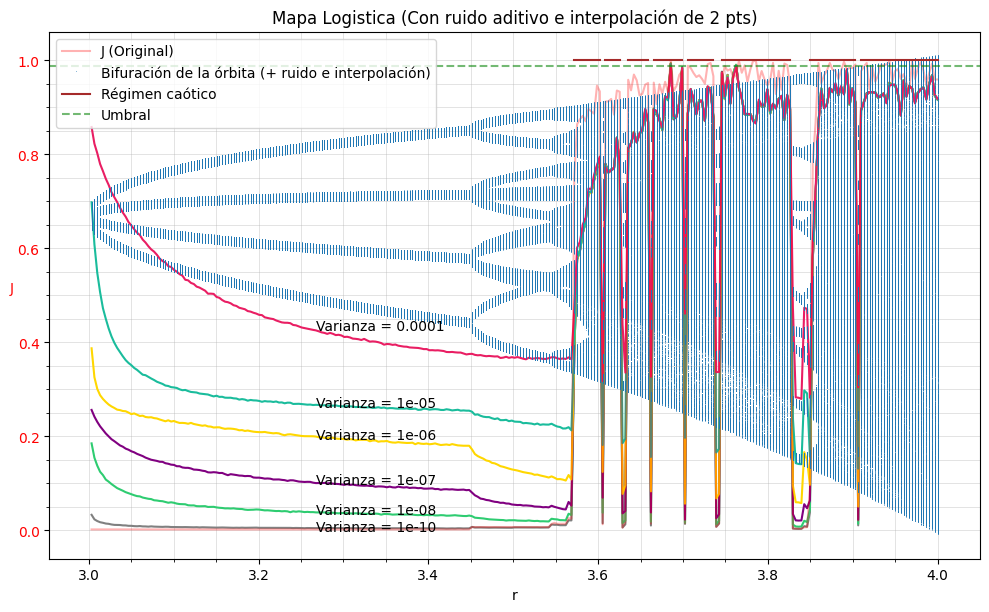

Correlación de Spearman: 0.6135160674877033


In [ ]:
"""logistic ruido multiple
NO EDITAR HASTA CORRER LOS PROMEDIOS
"""


def logistic_map(r, x):
    return r * x * (1 - x)

def plot_orbit_diagram(num_interp,discreto,interpolacion,graficar, r_min = 3.0, r_max = 4.0, num_points_per_r=300,
 num_iterations_discard=3000, num_iterations_display=2000):
    if interpolacion == "si":
        print("Interpolación")

    ruidos = [1e-10,1e-8,1e-7,1e-6,1e-5,1e-4]
    colores = ['gray','#2ECC71','purple', '#FFD700','#1ABC9C','#E91E63']
    J_por_ruido = []
    caotico = np.load('data/regimen_caotico.npy')
    for ruido in ruidos:   
        Jss = []
        vss = []
        for _ in range(100): 

            r_values = []
            orbit_values = []

            for r in np.linspace(r_min, r_max, num_points_per_r):
                
                x = 0.6
                if r == 3.0:
                    continue
                for _ in range(num_iterations_discard): # Converger
                    # x = np.clip(x, 0.0, 1.0)
                    x = logistic_map(r, x) #+ generar_uniforme_centrada(1, ruido)[0]
                
                for _ in range(num_iterations_display):
                    # x = np.clip(x, 0.0, 1.0)
                    x = logistic_map(r, x) #+ generar_uniforme_centrada(1, ruido)[0]
                    r_values.append(r)
                    orbit_values.append(x)
                
            #A partir de aqui, orbita continua de logistica completada
            a = 0
            b = 0
            J_values=[]
            J_index=[]
            lyapunov_values = []
            # varianzas = []
            
            r_values_interp = []
            orbit_values_interp = np.array([])
            ti, to = True, True
            for i in range(0, len(r_values) - 1):
                if r_values[i] != r_values[i+1]:
                    r_single_orbit = orbit_values[a:i+1]
                    a = i+1
                    if periodos_logistic[b] != "Caos":
                        r_single_orbit = r_single_orbit[:2000]
                    
                    if interpolacion == 'si':
                        x = np.arange(len(r_single_orbit))
                        # x_new, data_interp = interpolador(r_single_orbit, 'lineal', 15)
                        # data_interp = interpolador_estocastico(data_interp, 3)
                        data_interp = r_single_orbit
                        random_array = generar_uniforme_centrada(len(r_single_orbit),ruido)
                        data_interp = data_interp + random_array
                        x_new, data_interp = interpolador(data_interp, 'lineal', 2)
                        r_values_interp = r_values_interp + [r_values[i]]*len(data_interp)
                        orbit_values_interp = np.concatenate((orbit_values_interp, data_interp))

                        r_single_orbit = data_interp

                    # var = var_per_state(r_single_orbit, periodos_logistic[b])
                    # if var == "Caos":
                    #     varianzas.append(np.nan)
                    # else:
                    #     varianzas.append( np.sum(np.array(var))/periodos_logistic[b] )
                    # lyapunov = lyapunov_exponent_from_orbit(r_single_orbit, r_values[i])
                    # lyapunov_values.append(lyapunov)
                    J, angulos = J_univariante(r_single_orbit, 1, False)
                    J_values.append(J)
                    J_index.append(r_values[i])

                    b += 1
            
            #ultimo valor de r
            # lyapunov = lyapunov_exponent_from_orbit(orbit_values[a:], r_values[len(r_values) - 1])  
            # lyapunov_values.append(lyapunov)
            if interpolacion == 'si':
                x = np.arange(len(orbit_values[a:]))
                # x_new, data_interp = interpolador(orbit_values[a:], 'lineal', 15)
                # data_interp = interpolador_estocastico(data_interp, 3)
                data_interp = orbit_values[a:]
                random_array= generar_uniforme_centrada(len(data_interp),ruido)
                data_interp = data_interp + random_array
                x_new, data_interp = interpolador(data_interp, 'lineal', 2)
                r_values_interp = r_values_interp + [r_values[i]]*len(data_interp)
                orbit_values_interp = np.concatenate((orbit_values_interp, data_interp))
                r_single_orbit = data_interp

            J = J_univariante(r_single_orbit, 1, False)
            J_values.append(J)
            # varianzas.append(np.nan)
            J_index.append(r_values[len(r_values) - 1])
            Jss.append(J_values)
            # vss.append(varianzas)
        # np.save('logistic_map/ruidos_promedios_iterado/varianza_por_ruido_'+ str(ruido) + '.npy', vss)
        # np.save('logistic_map/ruidos_promedios_interp/J_por_ruido_'+ str(ruido) + '.npy', Jss)
        J_por_ruido.append(np.mean(Jss,axis=0))
        print(ruido)

    #A partir de aqui, lyapunob y J fueron calculados

    J_continuo = np.load('data\j_logistic_continuo.npy')
    # J_continuo = np.load('logistic_map\J_OG_muchosdatos.npy')
    
    if graficar == True:
        fig, ax1 = plt.subplots(figsize=(10,6))
        
        if discreto == "no":
            color = "red"
        elif discreto == "si":
            color = "gray"
        for i,ruido in enumerate(ruidos):
            ax1.plot(J_index, J_por_ruido[i], color=colores[i] , alpha = 1)
            ax1.annotate(f'Varianza = {ruido}', xy=(J_index[len(J_index)//4], J_por_ruido[i][len(J_index)//4]), xytext=(10, J_por_ruido[i][-1]),
                         textcoords='offset points', ha='left', va='center')

        if discreto == "si":
            ax1.plot(J_index, J_continuo, 'red',label='J (Original)', alpha = 0.3)
            if interpolacion == "si":
                ax1.plot(r_values_interp, orbit_values_interp, ',', label=f'Bifuración de la órbita (+ ruido e interpolación)', alpha=0.5)
            else: 
                ax1.plot(r_values, orbit_values, ',', label='Bifuración de la órbita + ruido', alpha=1)
        if discreto == "no":
            ax1.plot(r_values, orbit_values, ',', label='Bifurcación de la órbita', alpha=1)
        ax1.set_xlabel('r')
        ax1.plot(J_index, np.array(caotico), color ='brown',linestyle='-', label = 'Régimen caótico')
        ax1.axhline(y=0.9873, color='green', linestyle='--', alpha =0.55,label='Umbral')
        ax1.set_ylabel('J', color='r', rotation = 360)
        ax1.tick_params(axis='y', labelcolor='r')
        # ax1.set_ylim(0,1)
        ax1.legend(loc = 'upper left')
        

        if discreto == "no":
            ax2 = ax1.twinx()
            ax2.axhline(y=0, color='black', linestyle='--', alpha =0.55)
            ax2.plot(J_index, lyapunov_values, 'black', label = 'λ')
            ax2.set_ylabel('λ', color='black', rotation = 360)
            ax2.tick_params(axis='y', labelcolor='black')
            ax2.legend(loc='center right',framealpha=0.5)
        
        fig.tight_layout()  
        major_ticks_x = np.linspace(3, 4, 6)  # 0.0, 0.2, ..., 1.0
        minor_ticks_x = np.linspace(3, 4, 21)  # Ticks secundarios

        major_ticks_y = np.linspace(0, 1, 6)  # -1, -0.5, 0, 0.5, 1.0
        minor_ticks_y = np.linspace(0, 1, 21)  # Ticks secundarios

        # Configurar los ticks del eje X
        plt.xticks(major_ticks_x)  # Solo etiquetar los ticks principales
        plt.gca().set_xticks(minor_ticks_x, minor=True)  # Agregar ticks menores sin etiquetas

        # Configurar los ticks del eje Y
        plt.yticks(major_ticks_y)  # Solo etiquetar los ticks principales
        plt.gca().set_yticks(minor_ticks_y, minor=True)  # Agregar ticks menores sin etiquetas

        # Activar la cuadrícula
        plt.grid(which='major', linestyle='-', linewidth=0.5, alpha=0.5)  # Para ticks principales
        plt.grid(which='minor', linestyle='-', linewidth=0.5, alpha=0.5)  # Para ticks secundarios

        # plt.title(f'Logistic Map (Discret ={discreto}, interp= {interpolacion})')
        # plt.title(f'Mapa Logístico con discretización en el eje y ({num_partitions} Particiones)')
        plt.title(f'Mapa Logistica (Con ruido aditivo e interpolación de 2 pts)')
        plt.show()

    
    if interpolacion == 'no':
        return J_index, J_values, r_values, orbit_values, lyapunov_values
    else:
        return J_index, J_values, r_values_interp, orbit_values_interp, lyapunov_values 


with open('data/lyapunov_continuo.txt', 'r') as f:
        lyapunov_continuo = [float(line.strip()) for line in f]

J_continuo = np.load('data/J_OG_muchosdatos.npy')

J_index, J_values, r_values, orbit_values, lyapunov_values = plot_orbit_diagram(15,"si", "si", 20 ,True)
# J_index, J_values, r_values, orbit_values, lyapunov_values_continuo = plot_orbit_diagram(50,"no", "no", 20 ,True)


# Calcular correlación de Spearman
correlacion, p_valor = spearmanr(J_values, J_continuo)

print(f'Correlación de Spearman: {correlacion}')

Text(0.5, 1.0, 'Simulación de periodo-2 con incremento de separación d')

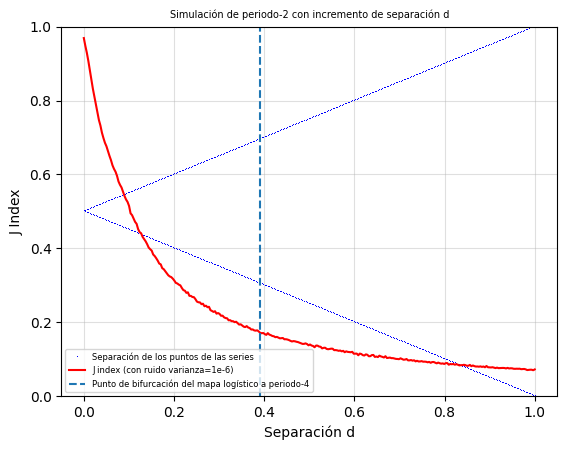

In [ ]:
Jss= np.load('data/periodos_simulados/J_periodo2_simulado_1e-6.npy')

Js=[]
x1 = 0.5
d = 0.07 
for d in np.linspace(0.0001,0.5,300):
    random = generar_uniforme_centrada(31985, 1e-6)
    array = np.array([x1-d,x1+d]*1000)
    x_index = [d*2]*len(array)
    plt.plot(x_index,array,',',color='blue')

plt.plot(x_index,array,',',color='blue',label='Separación de los puntos de las series')
plt.plot(np.linspace(0.0001,0.5,300)*2,np.mean(Jss,axis=0),color='red',label='J index (con ruido varianza=1e-6)')
plt.axvline(x = 0.39,linestyle='--', label = 'Punto de bifurcación del mapa logístico a periodo-4')
plt.xlabel('Separación d')
plt.ylabel('J Index')
plt.grid(alpha=0.4)
plt.ylim(0,1.0)
plt.legend(fontsize=6)

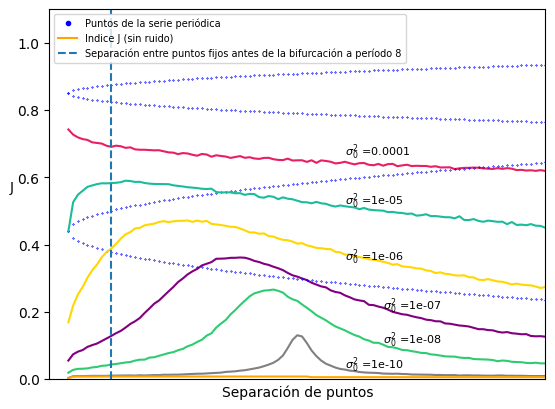

In [ ]:
"""NO EDITAR HASTA CORRER PROMEDIOS"""
ruidos = [1e-10,1e-8,1e-7,1e-4,1e-5,1e-6]
for l,ruido in enumerate(ruidos):
    x1 = 0.44
    x2 = 0.85
    d_1 = 0.2431*np.sqrt(np.linspace(0,15.5,550))
    d_2 = 0.1013*np.sqrt(np.linspace(0,15.5,550)) #0,15.5,550
    ruidos = [1e-10,1e-8,1e-7,1e-4,1e-5,1e-6]
    colores = ['gray','#2ECC71','purple','#E91E63','#1ABC9C', '#FFD700']
    Js=[]
    Js_ruido=[]
    for i,(d1,d2) in enumerate(zip(d_1,d_2)):
        array = [x2 -d2/2,x1 + d1/2,x2 + d2/2,x1 - d1/2]*5
        random = generar_uniforme_centrada(len(array), ruido)
        array_ruido = array + random
        x_index = [i]*len(array)
        Js_ruido.append(J_univariante(array_ruido,1,False))

        if ruido == 1e-5:
            plt.plot(x_index,array,'.',color='blue',markersize=0.5,alpha=0.5)
    Js = np.load('data/periodos_simulados/J_periodo4_simulado_OG.npy')
    Js_ruido = np.load('data/periodos_simulados/J_periodo4_simulado_'+ str(ruido) + '.npy')
    Js_ruido = np.mean(Js_ruido,axis=0)
    plt.plot(Js_ruido, color=colores[l] , alpha = 1)
    dist_x = 55
    dist_y = 10
    if ruido == 1e-8 or ruido == 1e-7:
        dist_x = 63
    if ruido == 1e-10:
        dist_y = 7
    plt.annotate(r'$\sigma_0^2$ ='+ f'{ruido}', xy=(dist_x, Js_ruido[75]), xytext=(10, Js_ruido[-1]+dist_y),
                    textcoords='offset points', ha='left', va='center',fontsize=8)
plt.plot(x_index,array,'.',color='blue',label='Puntos de la serie periódica',alpha=1)
plt.plot(Js,label='Indice J (sin ruido)',color='orange')
plt.axvline(x = 9,linestyle='--', label = 'Separación entre puntos fijos antes de la bifurcación a período 8')
plt.xlabel('Separación de puntos')
plt.ylabel('J',rotation=360)
plt.xticks([])
plt.ylim(0,1.1)
plt.xlim(-4,100)
plt.legend(fontsize=7,loc='upper left')
plt.show()


# Ruido sumado
$X_{t+1} = X_{t}r (1 - X_{t}) $ \
$X'_{t+1} = X_{t+1}  + \eta_{t} $ \
$X'_{t+2} = X_{t+2} + \eta_{t+1}$ \
$X'_{t+3} = X_{t+3} + \eta_{t+2}$

# Ruido iterado
$X'_{t+1} = X_{t+1} + \eta_{t} $ \
$X'_{t+2} = X'_{t+1} + \eta_{t+1} $ \
$X'_{t+3} = X'_{t+2} + \eta_{t+2} $ 